# Lånekalkulator
I denne oppgåva vil eg lage ein lånekalkulator som samanliknar serielån og annuitetslån. Brukaren skriv inn lånebeløp, rente, lånetid og avdrag per år ved å endre variablane i koden direkte. Programmet finn:
* månadleg avdrag for serielån
* terminbeløp for annuitetslån
* total betaling over låneperioden for både serielån og annuitetslån
* grafisk framstilling av korleis restlånet krympar over låneperioden
* kor mykje ein sparer på å velge serielån over annuitetslån

Dersom ein vel annuitetslån, vil ein betale kr. 12667.13 per termin, og det totale tilbakebtalingsbeløpet er kr. 4560166.8 . 

Dersom ein vel serielån blir det månadlege avdraget på kr. 6944.44 , og det totale tilbakebetalingsbeløpet er kr. 4192187.5 . 

Vi kan samalikne grafisk korleis restlånet endrar seg over låneperioden:
Dersom ein vel serielån over annutetslån, sparer ein kr. 367979.3


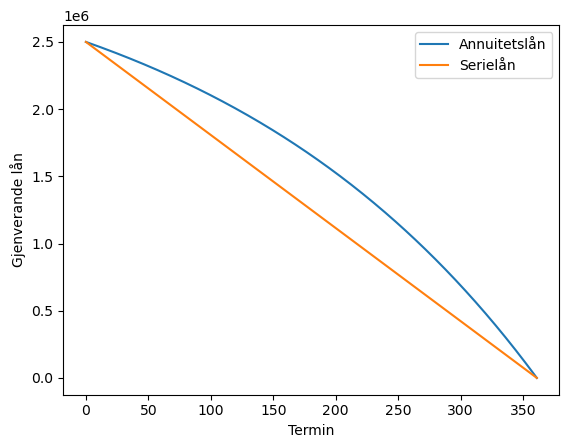

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Annuitetslån

lånebeløp = 2500000 
r = 0.045 #rente
lånetid = 30 
avdrag_per_år = 12
n = lånetid * avdrag_per_år
i = r / 12
n_serie = np.linspace(0, n+1, n+1)

D_a = np.round(lånebeløp * ((i * (1 + i)**n) / (((1 + i)**n) - 1)), 2)

a_lån = np.round(D_a * n, 2)


#Serielån

D_s = np.round(lånebeløp / n, 2)
s_rente = ((lånebeløp * i / 2) * (n + 1))

s_lån = np.round(s_rente + lånebeløp, 2)

print("Dersom ein vel annuitetslån, vil ein betale kr.", D_a, "per termin, og det totale tilbakebtalingsbeløpet er kr.", a_lån, ". \n")

print("Dersom ein vel serielån blir det månadlege avdraget på kr.", D_s, ", og det totale tilbakebetalingsbeløpet er kr.", s_lån, ". \n")

print("Vi kan samalikne grafisk korleis restlånet endrar seg over låneperioden:")

print("Dersom ein vel serielån over annutetslån, sparer ein kr.", np.round(a_lån - s_lån, 2))

annuitet = [lånebeløp]
for j in range(n):
    rente = annuitet[j] * i
    restlån_a = np.round(annuitet[j] + rente - D_a, 2)
    annuitet.append(restlån_a)

serie = [lånebeløp]
for j in range(n):
    restlån_s = np.round(serie[j] - D_s)
    serie.append(restlån_s)

#print(annuitet)

plt.plot(n_serie, annuitet)
plt.plot(n_serie, serie)
plt.xlabel("Termin")
plt.ylabel("Gjenverande lån")
plt.legend(["Annuitetslån", "Serielån"])